# Exploratory Data Analysis on the Cardiotocographic Dataset

## Objective
The objective of this analysis is to perform a systematic Exploratory Data Analysis (EDA) on the **Cardiotocographic** dataset. The analysis covers data loading, structure inspection, missing-value handling, data-type validation, outlier analysis, descriptive statistics, distribution analysis, categorical/target analysis, correlation analysis, pairwise relationships, pattern recognition, and a final conclusion.

> **Note:** The assignment description gives probable interpretations for several abbreviations such as LB, AC, FM, and UC. Those interpretations are retained as provided in the assignment rather than being silently replaced with external definitions. The actual CSV is treated as the source of truth for the columns and values present in the dataset.

## 1. Import Required Libraries

We use:
- **Pandas** for data loading, manipulation, and statistical summaries.
- **NumPy** for numerical operations.
- **Matplotlib** for plotting.
- **Seaborn** for statistical visualizations.

The plotting style is kept simple so that the figures remain suitable for an academic EDA submission.

In [1]:
# Import libraries required for the analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display more columns when printing DataFrames
pd.set_option("display.max_columns", None)

# Make plots readable
sns.set_theme(style="whitegrid")

## 2. Load the Dataset

The CSV file is loaded into a Pandas DataFrame. `df.head()` is used to verify that the file has been loaded correctly and to inspect the first few observations.

In [2]:
# Load the Cardiotocographic dataset
url = "https://raw.githubusercontent.com/Bumb1eBee20/ExcelR---Data-Science-Assignments-Submissions/6d3450df217e431d77c1e5b3c3aa1dce6974fa89/5.%20EDA/data/Cardiotocographic.csv"

df = pd.read_csv(url)

# Display the first five rows
df.head()

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
0,120.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,73.0,0.5,43.0,2.4,64.0,0.999926,2.0
1,132.000000,0.006380,0.0,0.006380,0.003190,0.0,0.0,17.0,2.1,0.0,10.4,130.0,0.000000,1.0
2,133.000000,0.003322,0.0,0.008306,0.003322,0.0,0.0,16.0,2.1,0.0,13.4,130.0,0.000000,1.0
3,134.000000,0.002561,0.0,0.007742,0.002561,0.0,0.0,16.0,2.4,0.0,23.0,117.0,1.000000,1.0
4,131.948232,0.006515,0.0,0.008143,0.000000,0.0,0.0,16.0,2.4,0.0,19.9,117.0,1.000000,1.0


In [3]:
# Display the last five rows
df.tail()

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
2121,140.0,0.000000,0.961268,0.007426,0.0,0.0,0.0,79.0,0.2,25.000000,7.2,40.0,0.0,2.000000
2122,140.0,0.000775,0.000000,0.006979,0.0,0.0,0.0,78.0,0.4,22.000000,7.1,66.0,1.0,2.000000
2123,140.0,0.000980,0.000000,0.006863,0.0,0.0,0.0,79.0,0.4,20.000000,6.1,67.0,1.0,1.990464
2124,140.0,0.000679,0.000000,0.006110,0.0,0.0,0.0,78.0,0.4,27.000000,7.0,66.0,1.0,2.000000
2125,142.0,0.001616,-0.000188,0.008078,0.0,0.0,0.0,74.0,0.4,35.857183,5.0,42.0,0.0,1.000000


## 3. Dataset Overview

Before performing any transformations, we inspect:
- Number of rows and columns
- Column names
- Data types
- Missing values
- Duplicate records
- Basic dataset information

This step is important because EDA should begin with understanding the raw data rather than immediately modifying it.

In [4]:
# Number of observations and variables
print("Number of rows    :", df.shape[0])
print("Number of columns :", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes)

print("\nDataset information:")
df.info()

Number of rows    : 2126
Number of columns : 14

Column names:
['LB', 'AC', 'FM', 'UC', 'DL', 'DS', 'DP', 'ASTV', 'MSTV', 'ALTV', 'MLTV', 'Width', 'Tendency', 'NSP']

Data types:


,0
LB,float64
AC,float64
FM,float64
UC,float64
DL,float64
DS,float64
DP,float64
ASTV,float64
MSTV,float64
ALTV,float64



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   LB        2105 non-null   float64
 1   AC        2106 non-null   float64
 2   FM        2126 non-null   float64
 3   UC        2126 non-null   float64
 4   DL        2126 non-null   float64
 5   DS        2105 non-null   float64
 6   DP        2105 non-null   float64
 7   ASTV      2126 non-null   float64
 8   MSTV      2126 non-null   float64
 9   ALTV      2126 non-null   float64
 10  MLTV      2105 non-null   float64
 11  Width     2105 non-null   float64
 12  Tendency  2105 non-null   float64
 13  NSP       2105 non-null   float64
dtypes: float64(14)
memory usage: 232.7 KB


In [5]:
# Check the number of duplicate rows
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 2


### Observation

The dataset contains **2,126 rows and 14 columns**. All columns are currently represented as numerical (`float64`) variables. Although the dataset contains no obvious text-based categorical columns, the `NSP` variable is intended to represent a class/target variable and therefore needs separate inspection.

The duplicate check is also performed before any cleaning so that potentially repeated observations are not accidentally overlooked.

## 4. Identify Numerical and Categorical Columns

The dataset is primarily numerical. We explicitly separate numerical variables from variables that may be treated as categorical/target variables.

`NSP` is handled separately because its values are intended to represent classes rather than a continuous measurement.

In [6]:
# Identify numerical columns
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()

# NSP is treated as the target/class variable for categorical analysis
target_column = "NSP"
feature_columns = [col for col in numeric_columns if col != target_column]

print("Numerical columns:")
print(feature_columns)

print("\nTarget column:")
print(target_column)

Numerical columns:
['LB', 'AC', 'FM', 'UC', 'DL', 'DS', 'DP', 'ASTV', 'MSTV', 'ALTV', 'MLTV', 'Width', 'Tendency']

Target column:
NSP


## 5. Missing-Value Analysis

Missing values can affect statistical calculations and machine-learning models. We first identify the number and percentage of missing observations in every column.

We do **not** immediately delete rows because that could unnecessarily reduce the dataset. For numerical features, median imputation is used later because the median is less sensitive to extreme observations than the mean.

In [7]:
# Count missing values in each column
missing_count = df.isnull().sum()

# Calculate missing percentage
missing_percentage = (missing_count / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage": missing_percentage.round(2)
}).sort_values("Missing Count", ascending=False)

display(missing_summary)

,Missing Count,Missing Percentage
LB,21,0.99
DS,21,0.99
MLTV,21,0.99
Width,21,0.99
Tendency,21,0.99
DP,21,0.99
NSP,21,0.99
AC,20,0.94
FM,0,0.00
UC,0,0.00


### Missing-Value Treatment

For the feature variables, missing values are filled using the **median of the corresponding column**. Median imputation is appropriate for this EDA because several variables contain skewed distributions and potential outliers.

For `NSP`, invalid or missing target values are not imputed. Since `NSP` is the target/class variable, fabricating a class label through imputation would introduce artificial information. Such observations are excluded only from target-dependent analysis.

In [8]:
# Create a working copy so the original raw dataset remains unchanged
df_clean = df.copy()

# Impute missing values in feature columns using their median
for col in feature_columns:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Report missing values after feature imputation
print("Missing values in features after median imputation:")
display(df_clean[feature_columns].isnull().sum().to_frame("Missing Values"))

# Keep the target untouched
print("\nMissing NSP values:", df_clean[target_column].isnull().sum())

Missing values in features after median imputation:


,Missing Values
LB,0
AC,0
FM,0
UC,0
DL,0
DS,0
DP,0
ASTV,0
MSTV,0
ALTV,0



Missing NSP values: 21


## 6. Data-Type Validation and Value Inspection

All columns are numeric in the loaded CSV. We still check for:
- Non-numeric values
- Infinite values
- Unexpected target values
- General value ranges

This is especially important because a numeric data type does not automatically mean that every numeric value is valid for analysis.

In [9]:
# Check for infinite values
infinite_values = np.isinf(df_clean[feature_columns]).sum()

print("Infinite values by feature:")
display(infinite_values.to_frame("Infinite Values"))

# Inspect minimum and maximum values
range_summary = pd.DataFrame({
    "Minimum": df_clean[feature_columns].min(),
    "Maximum": df_clean[feature_columns].max()
})

display(range_summary)

Infinite values by feature:


,Infinite Values
LB,0
AC,0
FM,0
UC,0
DL,0
DS,0
DP,0
ASTV,0
MSTV,0
ALTV,0


,Minimum,Maximum
LB,51.842487,214.000000
AC,-0.019284,0.038567
FM,-0.480634,0.961268
UC,-0.014925,0.030002
DL,-0.015393,0.030769
DS,-0.001353,0.002706
DP,-0.005348,0.010695
ASTV,-63.000000,162.000000
MSTV,-6.600000,13.800000
ALTV,-91.000000,182.000000


In [10]:
# Inspect the unique values occurring in the target variable
print("Number of unique NSP values:", df_clean[target_column].nunique(dropna=True))
print("\nNSP value frequencies:")
display(df_clean[target_column].value_counts(dropna=False).sort_index())

Number of unique NSP values: 111

NSP value frequencies:


,count
NSP,
-1.025988,1
-1.000000,5
0.967075,1
0.969447,1
0.972305,1
...,...
3.019152,1
3.020038,1
3.034545,1


### Important Data-Quality Finding

The uploaded CSV contains several `NSP` values that are not clean class labels (for example, non-integer decimal values and negative values), in addition to missing values. Therefore, `NSP` should **not** be blindly treated as a clean 1/2/3 categorical variable.

For class-frequency charts and target-based interpretation, we restrict the analysis to the expected integer class labels **1, 2, and 3**. This prevents malformed target values from being presented as legitimate classes.

This is a data-cleaning decision, not an assumption that the malformed values represent additional clinical categories.

In [11]:
# Define valid target classes for class-based analysis
valid_classes = [1, 2, 3]

# Create a dataset containing only valid NSP classes
df_target = df_clean[df_clean[target_column].isin(valid_classes)].copy()

print("Rows before target validation :", len(df_clean))
print("Rows with valid NSP classes   :", len(df_target))
print("Rows excluded from target analysis:",
      len(df_clean) - len(df_target))

# Convert NSP to integer category labels for plotting
df_target[target_column] = df_target[target_column].astype(int)

print("\nClean target distribution:")
display(df_target[target_column].value_counts().sort_index())

Rows before target validation : 2126
Rows with valid NSP classes   : 1990
Rows excluded from target analysis: 136

Clean target distribution:


,count
NSP,
1,1546
2,280
3,164


## 7. Descriptive Statistical Summary

The assignment asks for measures of central tendency and dispersion. We calculate:
- Count
- Mean
- Median
- Standard deviation
- Minimum and maximum
- First quartile (Q1)
- Third quartile (Q3)
- Interquartile range (IQR)

The IQR is calculated as:

**IQR = Q3 − Q1**

The IQR is particularly useful for identifying unusually distant observations without relying on the mean.

In [12]:
# Calculate descriptive statistics for the feature variables
summary = pd.DataFrame({
    "Count": df_clean[feature_columns].count(),
    "Mean": df_clean[feature_columns].mean(),
    "Median": df_clean[feature_columns].median(),
    "Std Dev": df_clean[feature_columns].std(),
    "Minimum": df_clean[feature_columns].min(),
    "Q1 (25%)": df_clean[feature_columns].quantile(0.25),
    "Q3 (75%)": df_clean[feature_columns].quantile(0.75),
    "Maximum": df_clean[feature_columns].max()
})

summary["IQR"] = summary["Q3 (75%)"] - summary["Q1 (25%)"]

display(summary.round(4))

,Count,Mean,Median,Std Dev,Minimum,Q1 (25%),Q3 (75%),Maximum,IQR
LB,2126,133.3402,133.0000,11.2144,51.8425,126.0000,140.0000,214.0000,14.0000
AC,2126,0.0032,0.0016,0.0044,-0.0193,0.0000,0.0056,0.0386,0.0056
FM,2126,0.0099,0.0000,0.0675,-0.4806,0.0000,0.0026,0.9613,0.0026
UC,2126,0.0044,0.0045,0.0033,-0.0149,0.0019,0.0065,0.0300,0.0047
DL,2126,0.0019,0.0000,0.0033,-0.0154,0.0000,0.0033,0.0308,0.0033
DS,2126,0.0000,0.0000,0.0001,-0.0014,0.0000,0.0000,0.0027,0.0000
DP,2126,0.0002,0.0000,0.0008,-0.0053,0.0000,0.0000,0.0107,0.0000
ASTV,2126,46.9960,49.0000,18.8140,-63.0000,32.0000,61.0000,162.0000,29.0000
MSTV,2126,1.3644,1.2000,1.1736,-6.6000,0.7000,1.7000,13.8000,1.0000
ALTV,2126,10.2860,0.0000,21.2050,-91.0000,0.0000,11.0000,182.0000,11.0000


### Interpretation of Descriptive Statistics

The variables have substantially different scales. For example, `LB`, `ASTV`, `ALTV`, and `Width` have much larger numerical ranges than variables such as `AC`, `UC`, `DS`, and `DP`.

Several variables also show a large difference between their mean and median. This suggests skewness and/or the influence of extreme observations. Variables with many zero values, such as some deceleration and movement-related measures, are particularly likely to have asymmetric distributions.

The standard deviation and IQR provide complementary information: standard deviation reflects overall spread, while IQR focuses on the middle 50% of observations.

## 8. Histograms

Histograms are used to understand the shape of each feature distribution. They help identify:
- Symmetry or skewness
- Concentration around particular values
- Long tails
- Multiple peaks
- Potential unusual observations

Because the variables have very different scales, each feature is plotted separately.

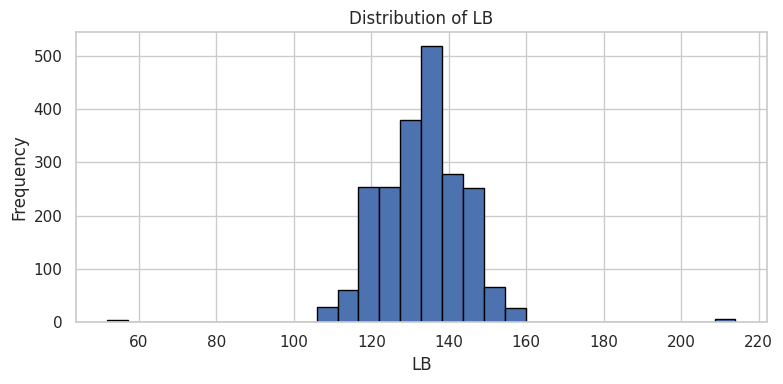

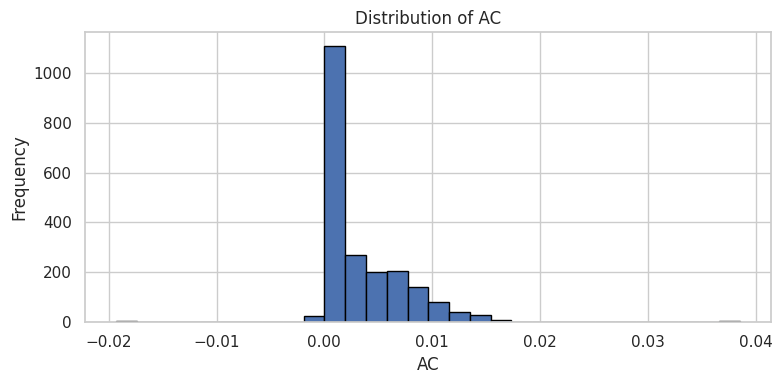

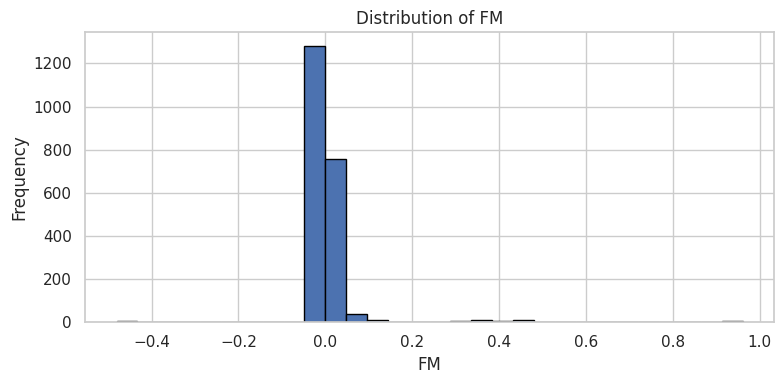

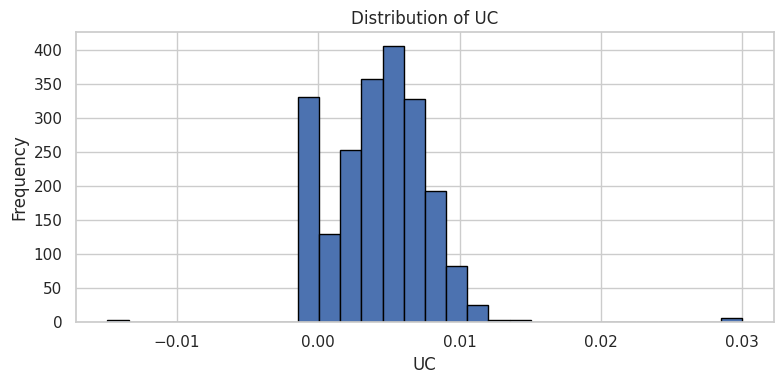

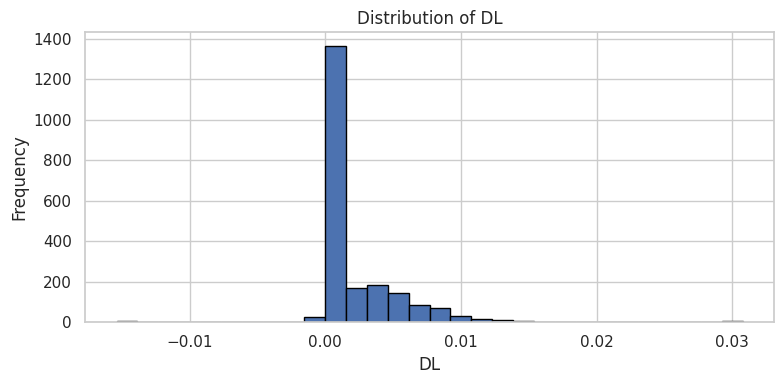

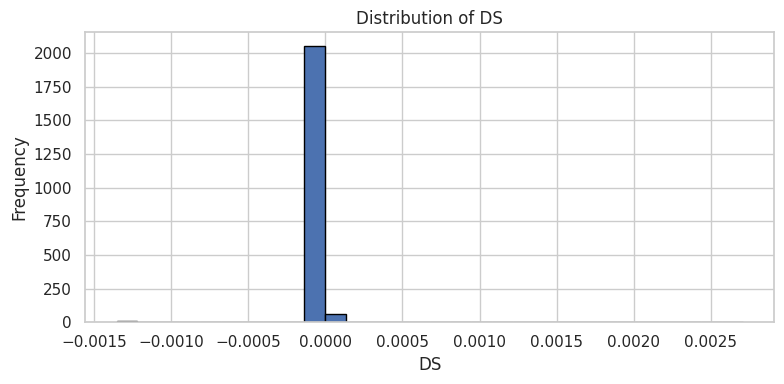

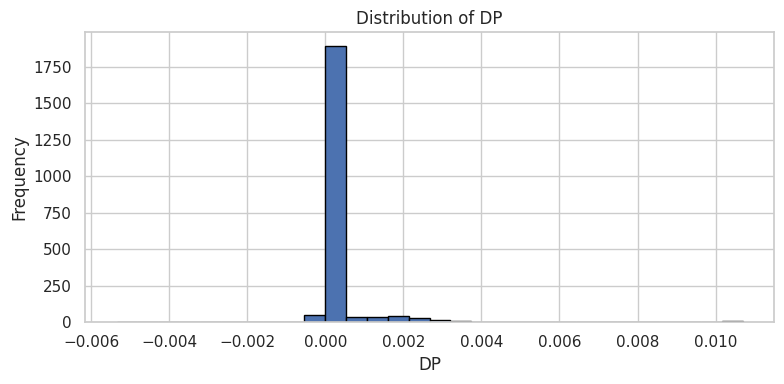

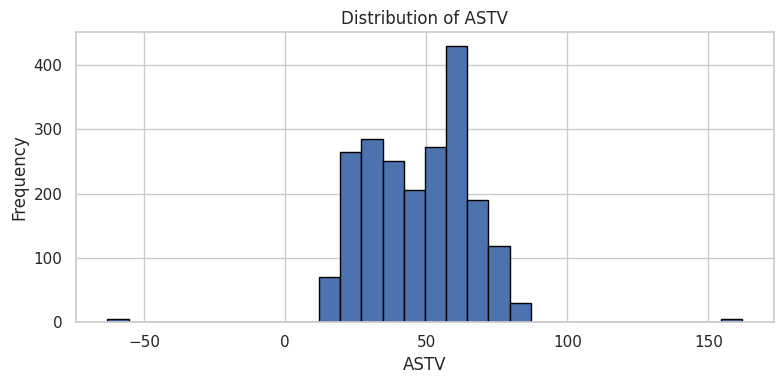

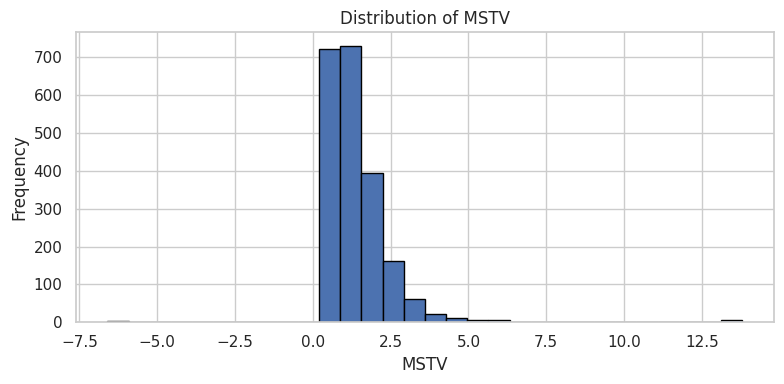

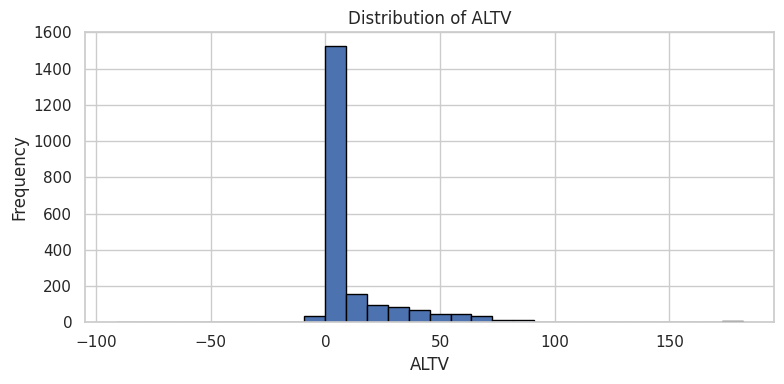

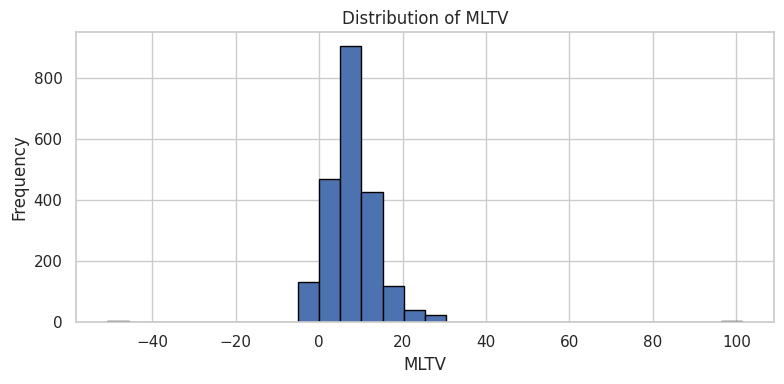

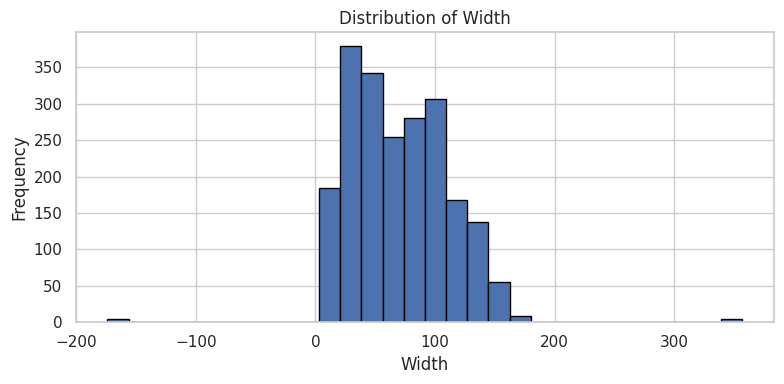

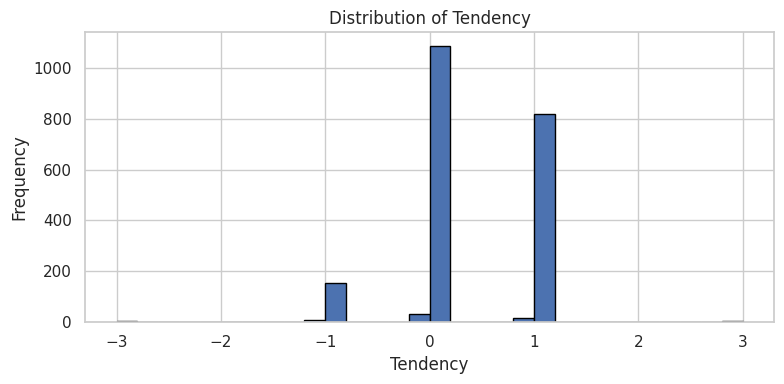

In [13]:
# Plot a histogram for every feature
for col in feature_columns:
    plt.figure(figsize=(8, 4))
    plt.hist(df_clean[col].dropna(), bins=30, edgecolor="black")
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

### Histogram Interpretation

The histograms should be interpreted feature-by-feature rather than assuming all variables follow the same distribution.

Features with a high concentration near zero and a long right tail are positively skewed. Such distributions are common in event/frequency-style measurements. A large difference between the mean and median in the descriptive table supports the presence of skewness.

The histograms also make the extreme values visible. These values should be investigated rather than automatically deleted, because statistical outliers can sometimes represent genuine observations.

## 9. Boxplots and Outlier Detection

A boxplot displays:
- Median
- Lower and upper quartiles
- Interquartile range
- Potential outliers

The standard IQR rule identifies a value as an outlier when:

- Lower bound = Q1 − 1.5 × IQR
- Upper bound = Q3 + 1.5 × IQR

This is used for **detection**, not automatic deletion.

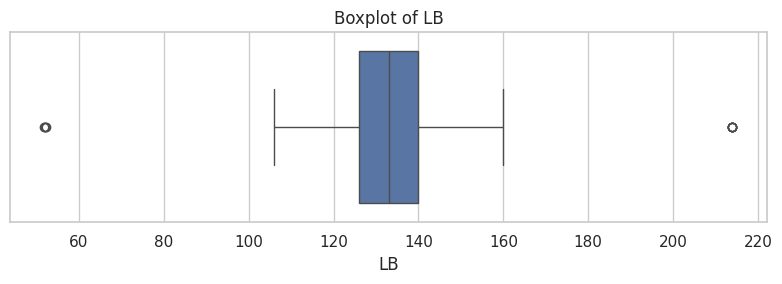

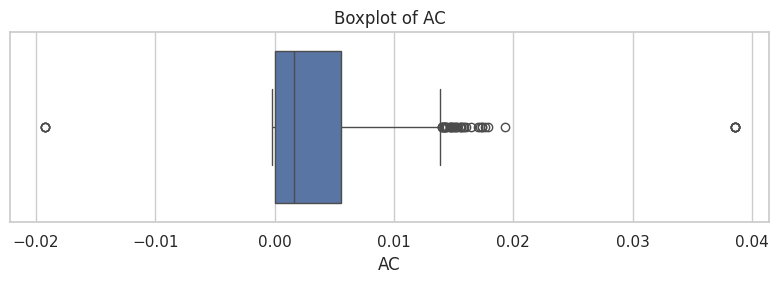

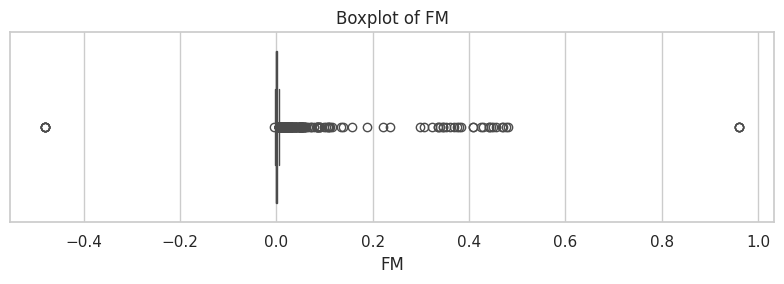

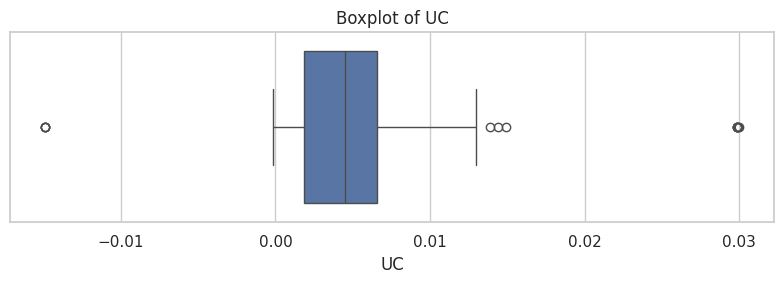

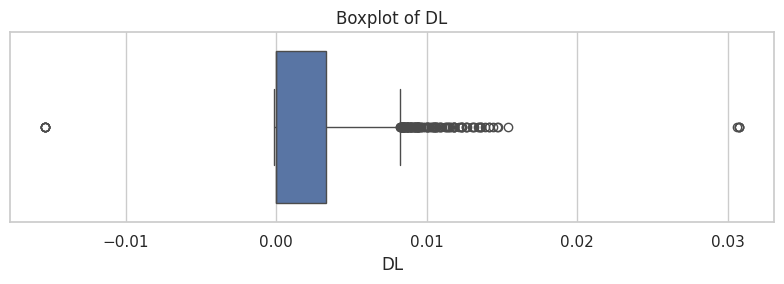

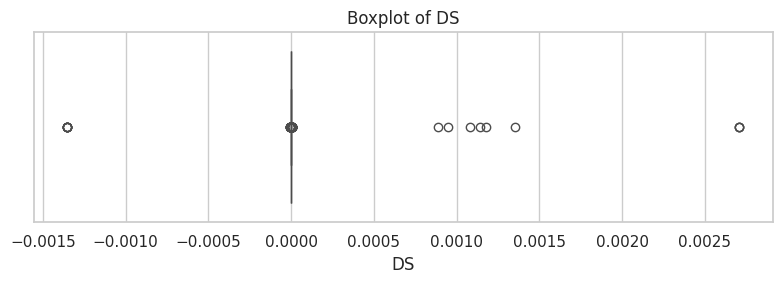

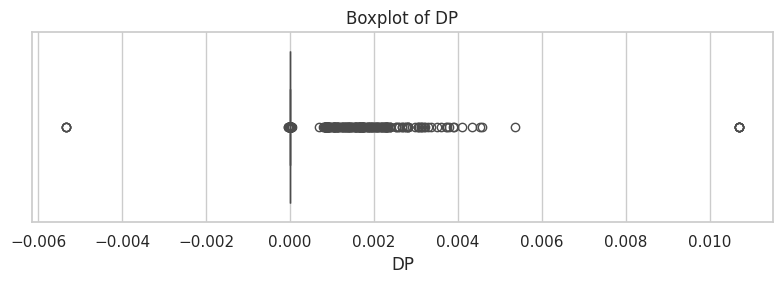

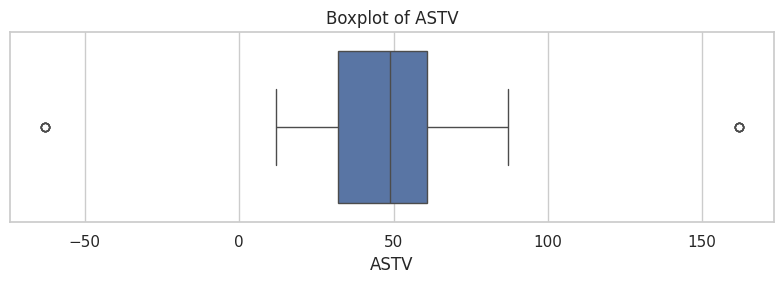

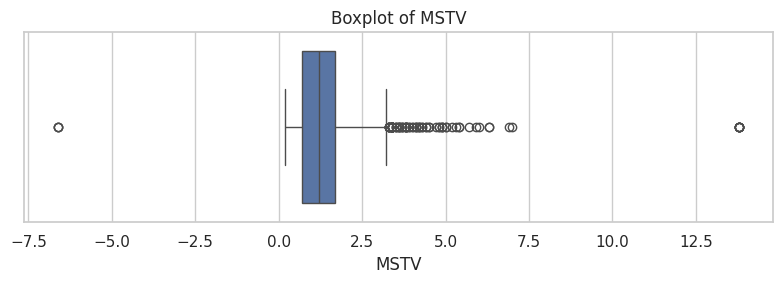

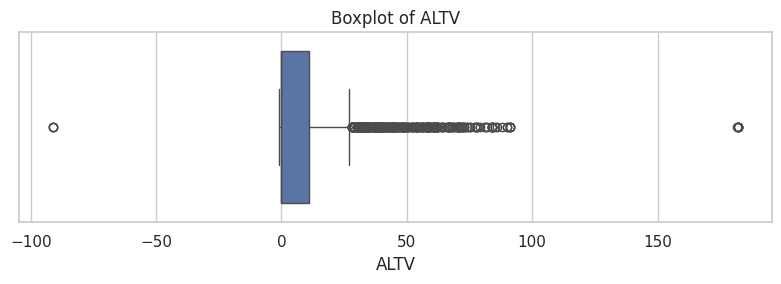

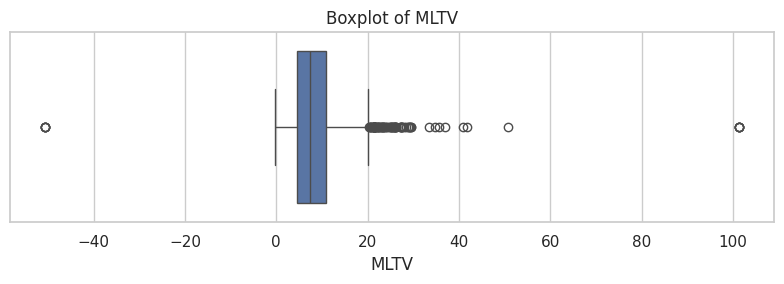

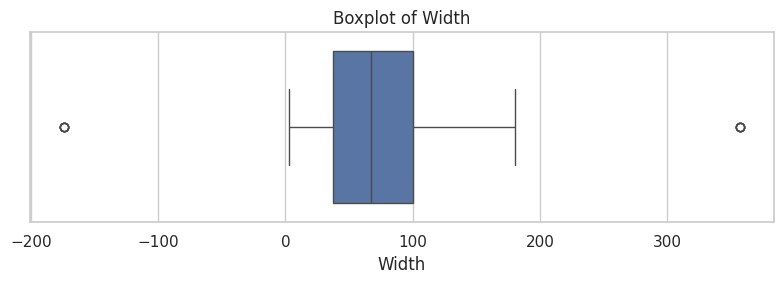

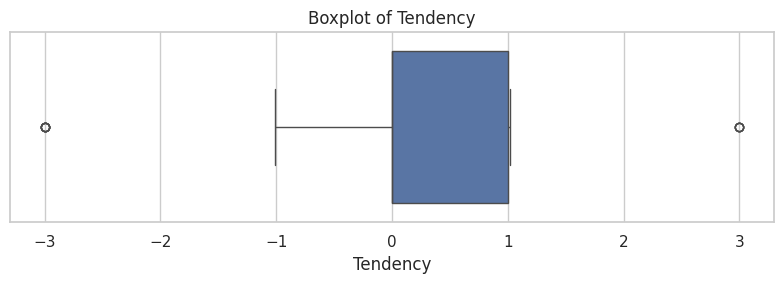

In [14]:
# Create boxplots for all feature variables
for col in feature_columns:
    plt.figure(figsize=(8, 3))
    sns.boxplot(x=df_clean[col])
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

In [15]:
# Calculate the number of IQR-based outliers for each feature
outlier_summary = []

for col in feature_columns:
    q1 = df_clean[col].quantile(0.25)
    q3 = df_clean[col].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outlier_count = ((df_clean[col] < lower_bound) |
                     (df_clean[col] > upper_bound)).sum()

    outlier_summary.append([
        col, q1, q3, iqr, lower_bound, upper_bound, outlier_count
    ])

outlier_summary = pd.DataFrame(
    outlier_summary,
    columns=[
        "Variable", "Q1", "Q3", "IQR",
        "Lower Bound", "Upper Bound", "Outlier Count"
    ]
)

outlier_summary["Outlier %"] = (
    outlier_summary["Outlier Count"] / len(df_clean) * 100
)

display(outlier_summary.sort_values("Outlier Count", ascending=False).round(4))

,Variable,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier %
2,FM,0.0000,0.0026,0.0026,-0.0038,0.0064,347,16.3217
9,ALTV,0.0000,11.0000,11.0000,-16.5000,27.5000,318,14.9577
6,DP,0.0000,0.0000,0.0000,0.0000,0.0000,284,13.3584
4,DL,0.0000,0.0033,0.0033,-0.0049,0.0082,125,5.8796
5,DS,0.0000,0.0000,0.0000,0.0000,0.0000,120,5.6444
10,MLTV,4.6000,10.8000,6.2000,-4.7000,20.1000,81,3.8100
8,MSTV,0.7000,1.7000,1.0000,-0.8000,3.2000,80,3.7629
1,AC,0.0000,0.0056,0.0056,-0.0084,0.0140,43,2.0226
3,UC,0.0019,0.0065,0.0047,-0.0052,0.0136,13,0.6115
0,LB,126.0000,140.0000,14.0000,105.0000,161.0000,10,0.4704


### Outlier Treatment Decision

The analysis identifies many statistical outliers in some variables. However, the presence of an IQR outlier does not automatically mean the observation is erroneous.

Therefore:
1. Outliers are **identified and reported**.
2. They are **not automatically deleted**.
3. Median imputation is used only for missing feature values.
4. The raw values are retained so that the EDA does not destroy potentially meaningful observations.

This is preferable to indiscriminate row deletion because removing hundreds of observations solely because they fall outside the IQR can introduce selection bias and change the underlying distribution.

## 10. Target/Class Distribution

`NSP` is treated as a categorical target for class-frequency analysis. Only valid classes 1, 2, and 3 are included, as described in the data-quality section.

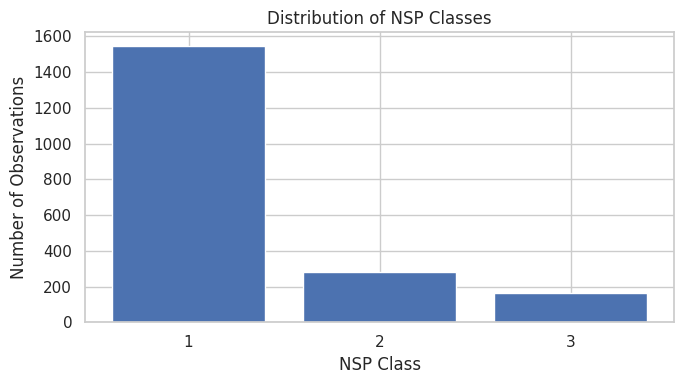

,Frequency
NSP,
1,1546
2,280
3,164


In [16]:
# Count observations in each valid NSP class
class_counts = df_target[target_column].value_counts().sort_index()

plt.figure(figsize=(7, 4))
plt.bar(class_counts.index.astype(str), class_counts.values)
plt.title("Distribution of NSP Classes")
plt.xlabel("NSP Class")
plt.ylabel("Number of Observations")
plt.tight_layout()
plt.show()

display(class_counts.to_frame("Frequency"))

### Interpretation

The class-distribution chart shows whether the target variable is balanced across classes. If one class occurs much more frequently than the others, the dataset is imbalanced.

Class imbalance is important for any later predictive modelling because a model can achieve apparently high accuracy by favoring the majority class. In such a situation, additional metrics such as precision, recall, F1-score, and a confusion matrix would be more informative than accuracy alone.

## 11. Correlation Matrix

Correlation analysis is used to examine linear relationships among the numerical variables.

The Pearson correlation coefficient ranges from **-1 to +1**:
- Values near +1 indicate a strong positive linear relationship.
- Values near -1 indicate a strong negative linear relationship.
- Values near 0 indicate a weak linear relationship.

Correlation does **not** imply causation.

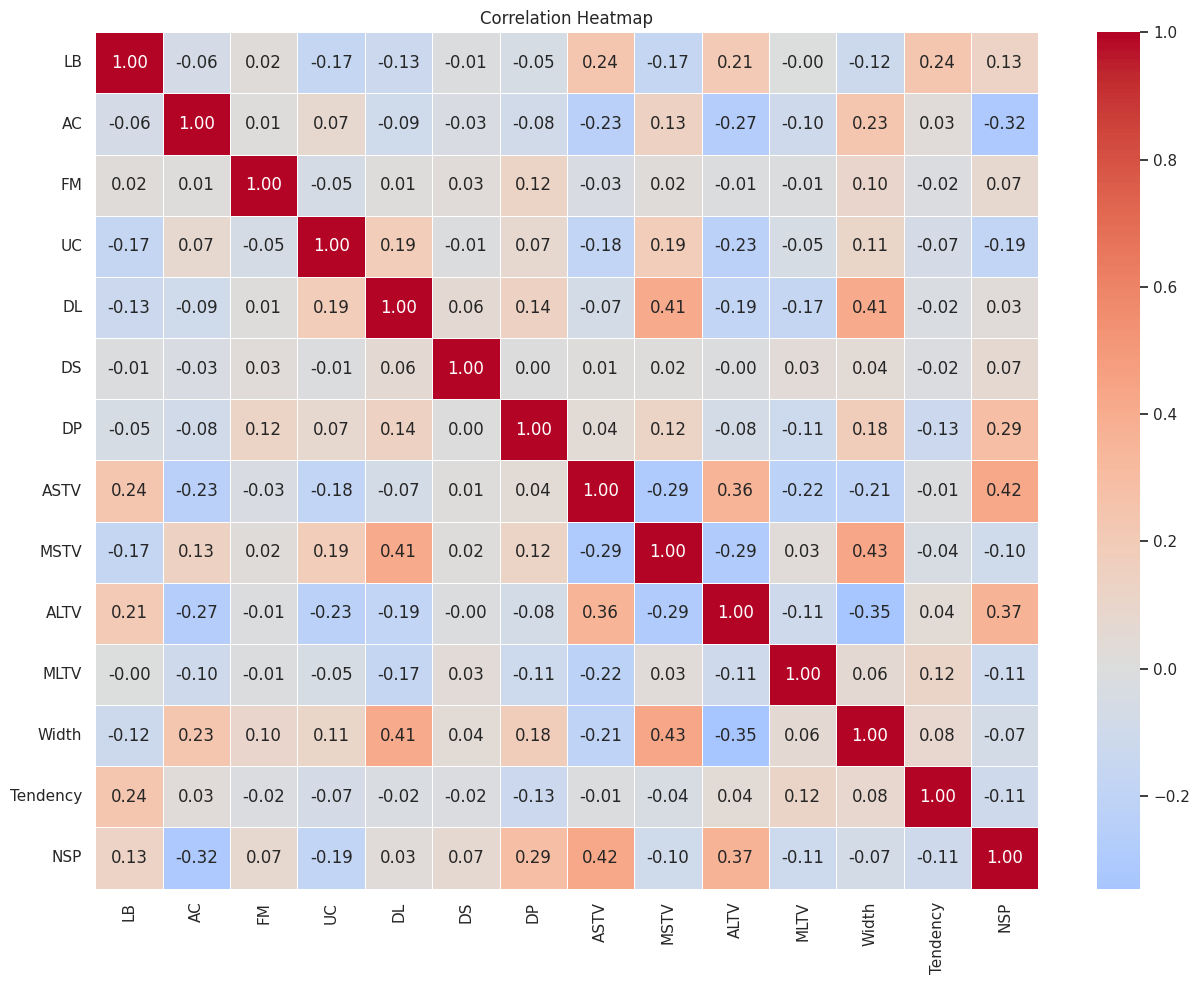

In [17]:
# Calculate the correlation matrix
corr_matrix = df_clean[numeric_columns].corr()

plt.figure(figsize=(13, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

## 12. Correlation with the Target

To make the relationship with `NSP` easier to interpret, we calculate the correlation of each feature with the target. This is an exploratory association only; it should not be interpreted as a causal relationship or as a final feature-importance ranking.

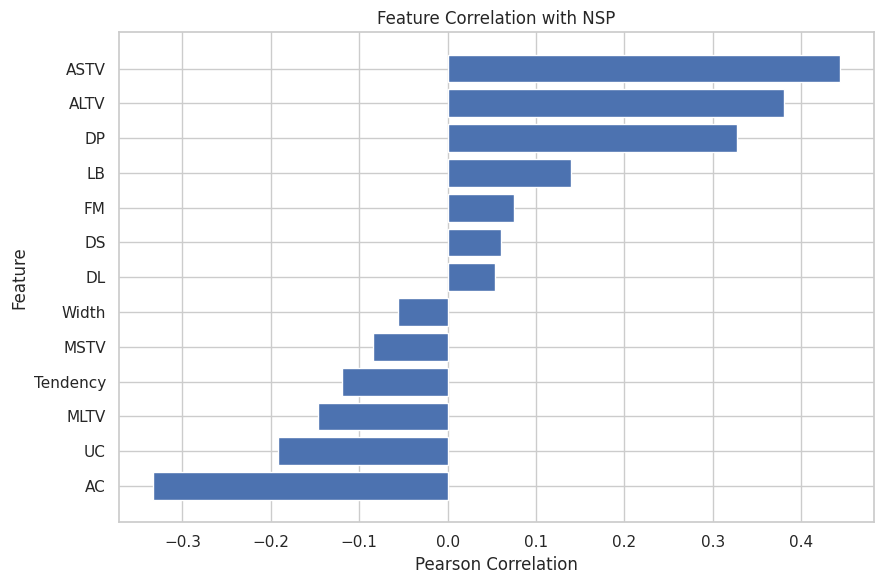

,Correlation with NSP
AC,-0.332907
UC,-0.191745
MLTV,-0.147075
Tendency,-0.119874
MSTV,-0.083943
Width,-0.055734
DL,0.053129
DS,0.060285
FM,0.075079
LB,0.139328


In [18]:
# Correlation of each feature with NSP
target_correlations = (
    df_target[feature_columns + [target_column]]
    .corr()[target_column]
    .drop(target_column)
    .sort_values()
)

plt.figure(figsize=(9, 6))
plt.barh(
    target_correlations.index,
    target_correlations.values
)
plt.title("Feature Correlation with NSP")
plt.xlabel("Pearson Correlation")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

display(target_correlations.to_frame("Correlation with NSP"))

### Key Correlation Findings

Based on the uploaded data, the strongest observed associations with `NSP` are approximately:

- **ASTV:** +0.42
- **ALTV:** +0.37
- **AC:** −0.32
- **DP:** +0.29
- **UC:** −0.19

The remaining variables show weaker linear relationships with `NSP`.

These values indicate association, not causation. They also do not establish that a feature is clinically important or that it should automatically be selected for a predictive model.

## 13. Scatter Plots for Important Relationships

Scatter plots allow us to visually inspect whether relationships suggested by the correlation matrix are approximately linear or are being driven by a small number of extreme observations.

The plots below focus on the features with relatively stronger absolute correlations with `NSP`.

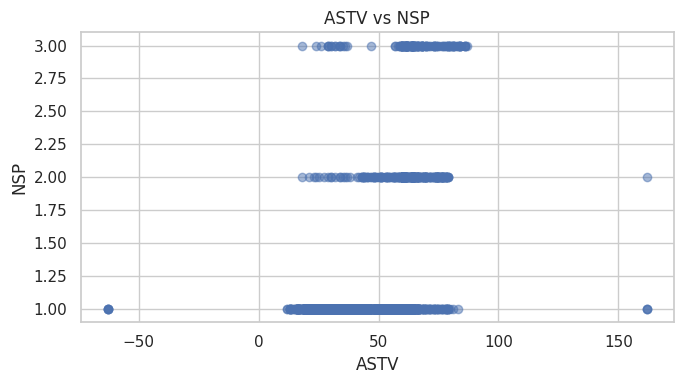

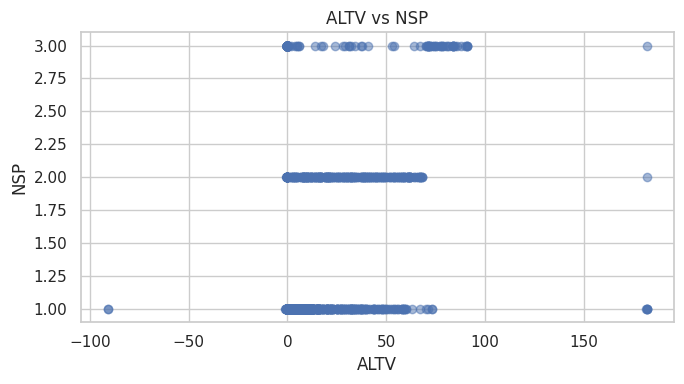

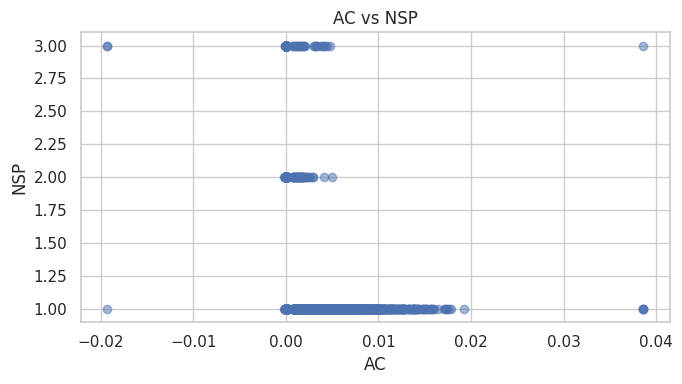

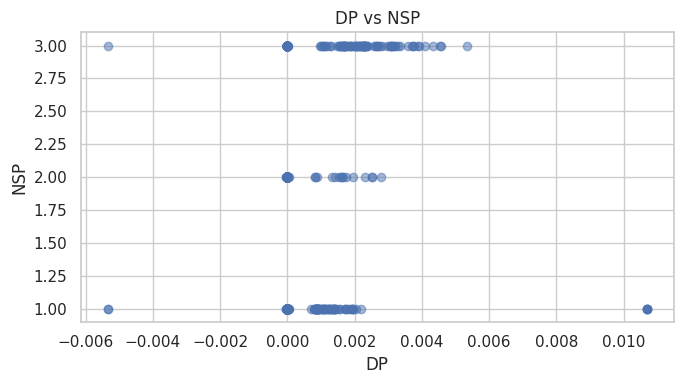

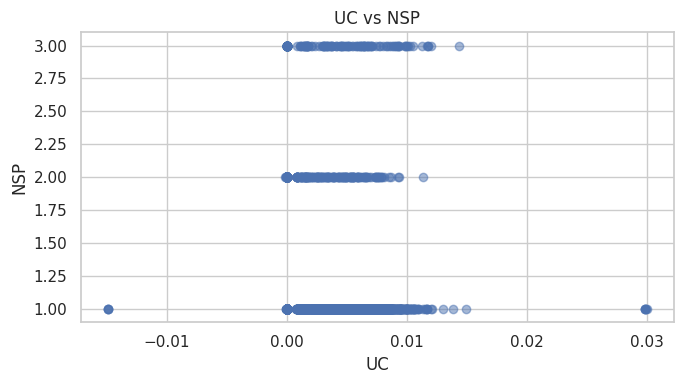

In [19]:
# Select features with relatively stronger absolute correlations
important_features = ["ASTV", "ALTV", "AC", "DP", "UC"]

for col in important_features:
    plt.figure(figsize=(7, 4))
    plt.scatter(df_target[col], df_target[target_column], alpha=0.5)
    plt.title(f"{col} vs NSP")
    plt.xlabel(col)
    plt.ylabel("NSP")
    plt.tight_layout()
    plt.show()

### Interpretation

The scatter plots should be read together with the correlation coefficients. Because `NSP` represents discrete classes, points appear in horizontal bands rather than forming a continuous cloud.

The visualizations help confirm whether the observed correlations are broadly distributed across the dataset or are strongly influenced by a small number of extreme observations.

## 14. Pair Plot

A pair plot provides a compact view of pairwise relationships and distributions. Since plotting every feature at once can become difficult to read, a selected subset of important variables is used.

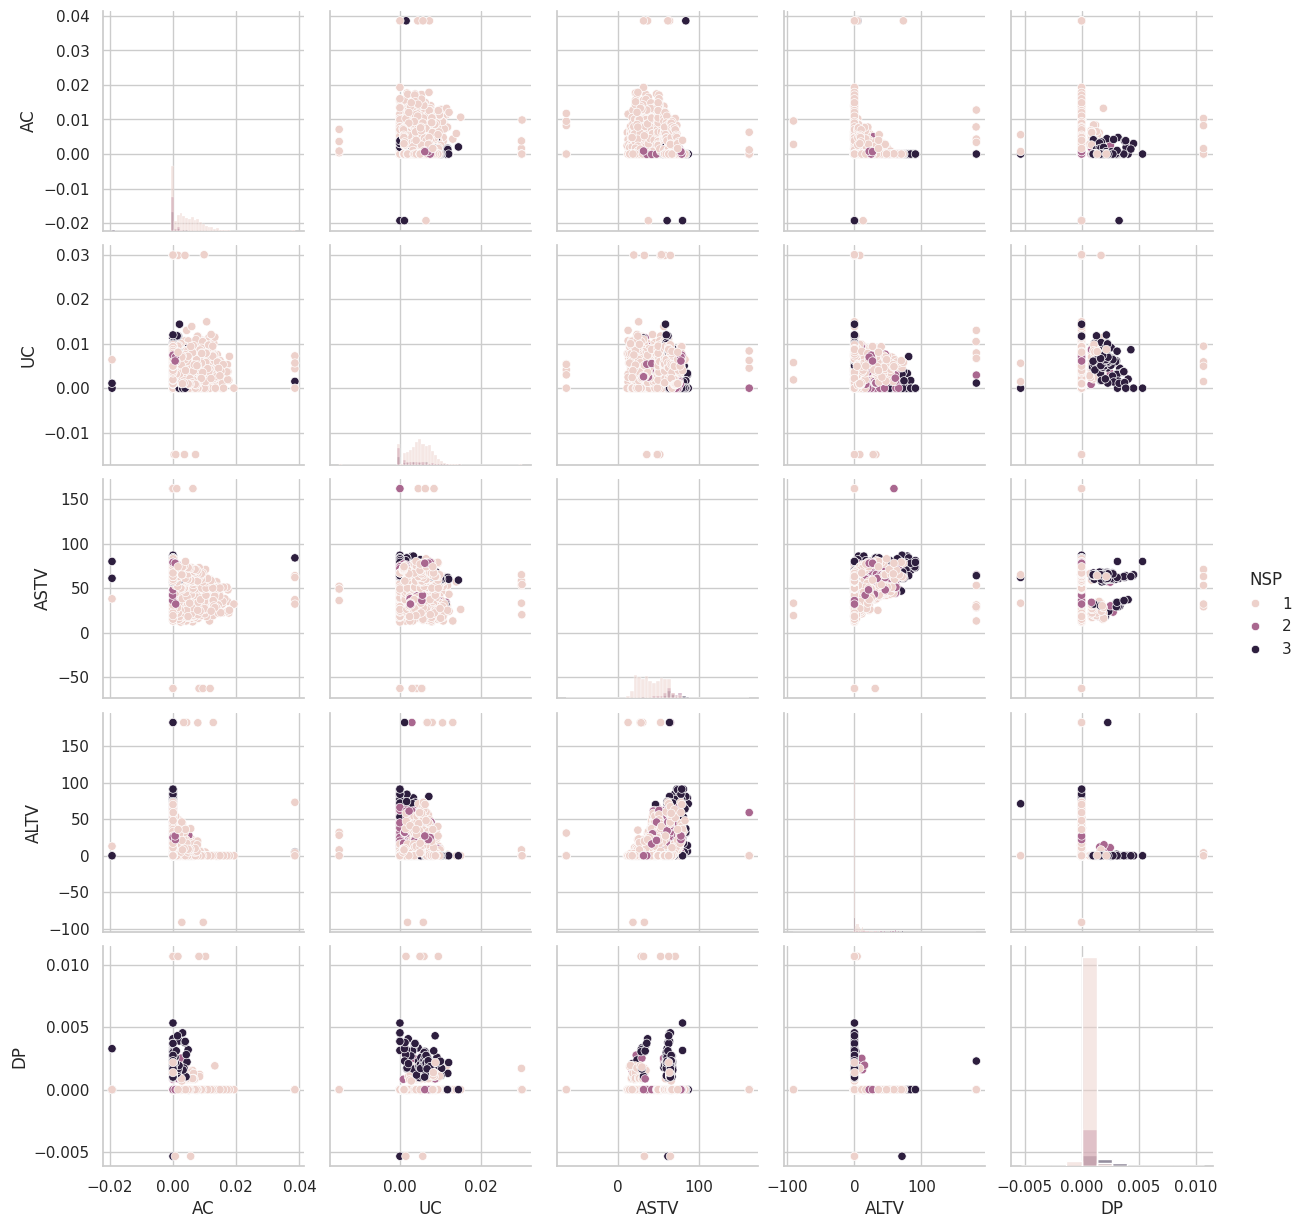

In [20]:
# Pair plot using selected variables
pairplot_columns = ["AC", "UC", "ASTV", "ALTV", "DP", "NSP"]

sns.pairplot(
    df_target[pairplot_columns],
    hue="NSP",
    diag_kind="hist"
)

plt.show()

### Interpretation of Pair Plot

The pair plot provides three useful views simultaneously:
- Diagonal plots show individual variable distributions.
- Off-diagonal plots show pairwise relationships.
- Different `NSP` classes can be visually compared.

Overlapping class distributions indicate that a single variable may not be sufficient to distinguish classes. This supports the idea that any later predictive analysis should consider multiple variables jointly.

## 15. Violin Plots

Violin plots combine information about the distribution and density of observations. They are useful for comparing how feature distributions differ across `NSP` classes.

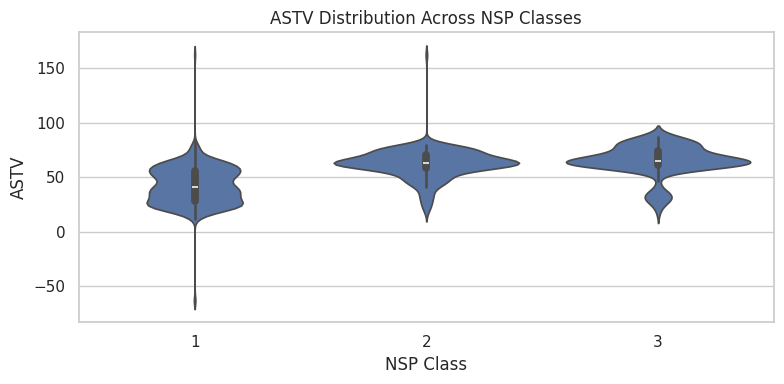

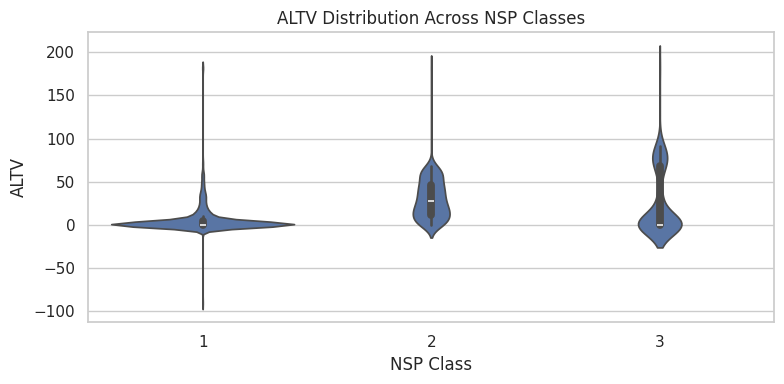

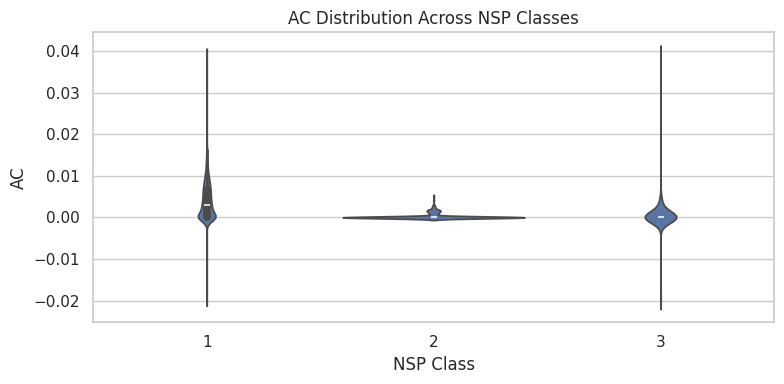

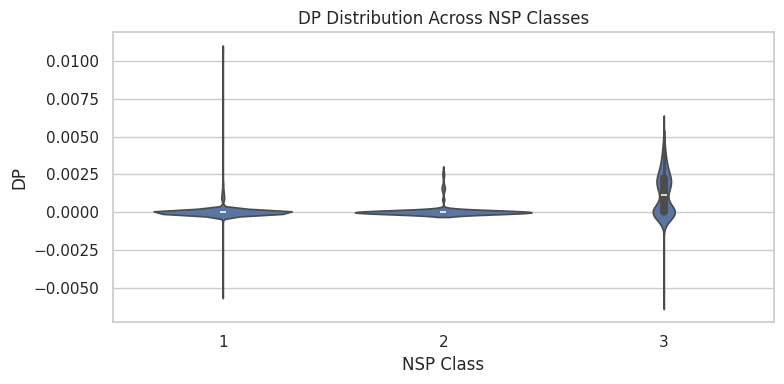

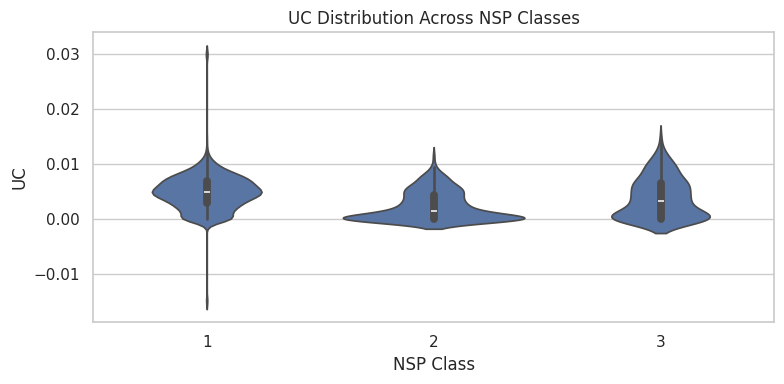

In [21]:
# Compare selected features across NSP classes
for col in important_features:
    plt.figure(figsize=(8, 4))
    sns.violinplot(data=df_target, x="NSP", y=col)
    plt.title(f"{col} Distribution Across NSP Classes")
    plt.xlabel("NSP Class")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

## 16. Feature-Wise Summary by NSP Class

Grouping the cleaned observations by `NSP` allows us to compare the mean and median of the features across the three valid classes.

In [22]:
# Calculate class-wise mean values
class_mean = df_target.groupby(target_column)[feature_columns].mean().T
display(class_mean.round(4))

NSP,1,2,3
LB,131.9198,141.8200,131.8833
AC,0.0041,0.0003,0.0004
FM,0.0076,0.0189,0.0222
UC,0.0048,0.0023,0.0038
DL,0.0019,0.0007,0.0035
DS,-0.0000,0.0000,0.0000
DP,0.0001,0.0001,0.0012
ASTV,42.2073,61.9638,64.9994
MSTV,1.4612,0.7198,1.5424
ALTV,5.4558,29.6546,24.2341


In [23]:
# Calculate class-wise median values
class_median = df_target.groupby(target_column)[feature_columns].median().T
display(class_median.round(4))

NSP,1,2,3
LB,132.0000,143.0000,132.0000
AC,0.0030,0.0000,0.0000
FM,0.0000,0.0000,0.0010
UC,0.0049,0.0013,0.0032
DL,0.0000,0.0000,0.0022
DS,0.0000,0.0000,0.0000
DP,0.0000,0.0000,0.0011
ASTV,41.0000,63.0000,65.0000
MSTV,1.3000,0.4943,1.6500
ALTV,0.0000,27.0000,0.0000


### Interpretation

Class-wise summaries help identify variables whose typical values change across `NSP` groups. These differences are useful for generating hypotheses and selecting variables for subsequent modelling.

However, differences in group means or medians alone do not prove that a feature can reliably classify observations. Predictive performance should be evaluated using a proper train/test split or cross-validation.

## 17. Overall EDA Findings

### Dataset Structure
- The uploaded dataset contains **2,126 observations and 14 variables**.
- The variables are stored as numerical values.
- There are no conventional text/string categorical columns.

### Missing Values
- Missing values occur in several variables.
- Feature missing values were handled using **median imputation**.
- Missing target values were not fabricated and were excluded from class-based target analysis.

### Data Quality
- The uploaded `NSP` column contains malformed/non-standard values in addition to the expected class labels.
- Only valid classes **1, 2, and 3** were used for categorical target analysis.
- This prevents invalid target values from distorting class-frequency analysis.

### Distributions
- Several variables are strongly skewed and/or concentrated around zero.
- Mean and median differences indicate that some distributions are not symmetric.
- Boxplots reveal substantial statistical outliers in multiple features.

### Correlation
- `ASTV` has the strongest positive linear association with `NSP` among the supplied variables.
- `ALTV` and `DP` also show positive associations.
- `AC` shows the strongest negative association with `NSP`.
- Correlation values should be interpreted as exploratory associations rather than causal relationships.

# 18. Conclusion

The exploratory analysis provides a detailed understanding of the Cardiotocographic dataset before any predictive modelling is attempted. The dataset contains 2,126 observations across 14 numerical variables. Initial inspection revealed missing values, substantial variation in feature scales, skewed distributions, and statistical outliers.

Missing feature values were handled using median imputation, while missing and malformed target values were not artificially imputed. Because the `NSP` column contains values outside the expected class labels, class-based analysis was restricted to valid classes 1, 2, and 3.

The visual analysis shows that several variables are highly skewed and contain extreme observations. The correlation analysis indicates that `ASTV`, `ALTV`, `AC`, `DP`, and `UC` have comparatively stronger linear associations with `NSP`. However, no individual correlation should be interpreted as proof of causation or as sufficient evidence for predictive usefulness.

Overall, the EDA suggests that the dataset contains meaningful structure but also requires careful data validation. The next logical step would be a supervised machine-learning analysis using appropriate preprocessing, a train/test split or cross-validation, and evaluation metrics such as precision, recall, F1-score, and a confusion matrix, particularly if the target classes are imbalanced.